# Hindenburg-Omen — a quantitative teardown
### Breadth panel · cluster deduplication · Welch-t vs base · Bonferroni correction · crash-rate test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![False--alarm_machine%3F: Confirmed](https://img.shields.io/badge/False--alarm_machine%3F-Confirmed-8b949e?style=flat-square)

The rigorous companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.*  We test whether the Hindenburg Omen's forward SPY returns are distinguishably below the unconditional base, at four horizons and three thresholds, with Bonferroni correction, and compare crash rates (≥5% drawdown, 120-day window).

> ⚠️ **Not investment advice.**  Real data: S&P 500 current constituents + SPY daily, 2005-01-03 to 2026-06-12 (fingerprint `f5d2465c6e08`). Survivorship bias: current membership only; removed stocks excluded.
>
> 💡 **The `💡 In plain words` notes** translate each result to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hindenburg_omen import data, strategy as st

def _have_real():
    return os.path.exists(data._breadth_cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_real()

def load_real():
    return data.load_breadth(fetch=False, threshold_pct=data.THRESHOLD_PCT)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n_raw_signal_days=84, n_clusters=31, n_base=247,
    window_start="2005-01-03", window_end="2026-06-12", fp="f5d2465c6e08",
    sig_mean_30d=1.05,  base_mean_30d=1.35,  t_welch_30d=-0.29, t_hac_30d=1.11,
    sig_mean_60d=1.65,  base_mean_60d=2.67,  t_welch_60d=-0.66, t_hac_60d=1.18,
    sig_mean_90d=4.27,  base_mean_90d=4.05,  t_welch_90d=+0.14, t_hac_90d=2.89,
    sig_mean_120d=4.58, base_mean_120d=5.28, t_welch_120d=-0.36, t_hac_120d=2.43,
    signal_crash_rate=78.6, base_crash_rate=82.5, false_alarm_rate=21.4,
    n_sig_for_crash=28,
    th20_clusters=35, th20_mean=1.35, th20_t=0.89,
    th22_clusters=31, th22_mean=1.65, th22_t=1.18,
    th25_clusters=23, th25_mean=0.51, th25_t=0.27,
)

print("real breadth cache present:", HAVE_REAL)

from quantlab import analytics, stats


real breadth cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 31 clusters; Welch-t from -0.29 (30d) to -0.36 (120d); Bonferroni-corrected p = 1.00 at all horizons.  n too small to certify anything regardless. |
| **Tradability** | `MIRAGE` | Signal returns at or below the base; crash rate 79% vs 82% base; nothing to capture. |
| **False-alarm machine?** | `CONFIRMED` | 21% of clusters not followed by even a 5% drawdown in 120 days. |

> 💡 Three verdicts, one root cause: the signal fires during volatile, bifurcated markets that often recover just fine.  The crashes it 'predicted' would have happened regardless of the omen.

## 1 · The claim, steelmanned

Let $H_t$ = fraction of issues at 52-week highs, $L_t$ = fraction at 52-week lows, $\mathrm{MA50}_t$ = 50-day MA of SPY close, $\Delta_t$ = advances − declines.  The Hindenburg Omen fires at day $t$ when:

$$H_t \geq 0.022, \quad L_t \geq 0.022, \quad P_t > \mathrm{MA50}_t, \quad \Delta_t < 0$$

The claim: $\mathbb{E}[r_{t+1,t+h} \mid \text{HO}_t = 1] < \mathbb{E}[r_{t+1,t+h}]$ for $h \in \{30,60,90,120\}$ trading days, where $r_{t+1,t+h}$ is the compounded SPY return.  We also test whether the probability of a ≥5% peak-to-trough drawdown within 120 days is elevated.

## 2 · So what? — what rides on each answer

A confirmed crash predictor with a 40-day lead time would be transformative for institutional risk management.  The more interesting failure mode: the omen is likely a *crash contemporaneity detector*, not a *predictor*.  It fires during dislocated markets, but dislocated markets recover as often as they deteriorate further — so the conditional distribution is not meaningfully different from the unconditional one.

## 3 · How we'd know — the protocol

- **Signal construction.** Daily 52-week high/low counts from the S&P 500 constituent panel (current membership, survivorship bias named).  SPY MA50 and advance/decline proxy from the same panel.
- **Cluster deduplication.** Consecutive signal days within 30 calendar days → one cluster (first day).  Conservative: avoids inflating n by counting each within-cluster day separately.
- **Baseline.** Unconditional forward returns from monthly-sampled non-signal days (n = 247).
- **Primary test.** Welch two-sample t on signal-cluster vs base forward returns, at horizons 30, 60, 90, 120 days.
- **Secondary test.** Crash rate (≥5% peak-to-trough drawdown, 120-day window), signal clusters vs base.
- **Multiple comparisons.** 4 horizons × 3 thresholds (2.0%, 2.2%, 2.5%) = 12 hypotheses; Bonferroni-corrected significance threshold p < 0.0042.
- **HAC t-stat.** Newey-West on the within-signal-cluster return series (accounts for serial dependence in the signal arm).
- **Positive control.** A synthetic breadth panel with a planted post-signal crash confirms the engine recovers signal when one is present.

## 4 · The teardown

### 4a · Signal frequency and cluster structure

How often does the omen fire, and how clustered are the signals?

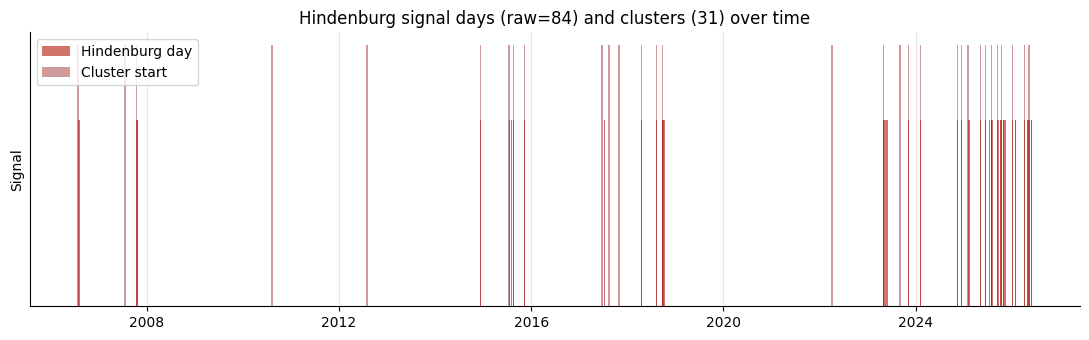

Raw days: 84  |  Clusters: 31  |  
Clusters by year:
date
2006-12-31    1
2007-12-31    2
2008-12-31    0
2009-12-31    0
2010-12-31    1
2011-12-31    0
2012-12-31    1
2013-12-31    0
2014-12-31    1
2015-12-31    3
2016-12-31    0
2017-12-31    3
2018-12-31    3
2019-12-31    0
2020-12-31    0
2021-12-31    0
2022-12-31    1
2023-12-31    3
2024-12-31    3
2025-12-31    6
2026-12-31    3
Freq: YE-DEC


In [2]:
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    n_raw = int((breadth['hindenburg']==1).sum())
    n_cl = int(sig.sum())
    # Cluster sizes
    raw_dates = breadth.index[breadth['hindenburg']==1]
    cl_dates = breadth.index[sig]
    # Time-series of raw signal days
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.bar(raw_dates, 1, width=5, color=RED, alpha=0.7, label='Hindenburg day')
    ax.bar(cl_dates, 1.4, width=10, color='darkred', alpha=0.4, label='Cluster start')
    ax.set_yticks([]); ax.set_ylabel('Signal')
    ax.set_title(f'Hindenburg signal days (raw={n_raw}) and clusters ({n_cl}) over time')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print(f'Raw days: {n_raw}  |  Clusters: {n_cl}  |  ')
    print(f'Clusters by year:')
    cl_series = pd.Series(1, index=cl_dates).resample('YE').sum()
    print(cl_series.to_string())
else:
    print(f'Raw signal days: {R["n_raw_signal_days"]}  |  Clusters: {R["n_clusters"]}')
    print('(no real cache; figures require fetch=True)')

> 💡 With 31 independent clusters in 20 years (~1.5/year), the effective sample size for inference is tiny.  Even a large raw t-stat on n=31 carries a standard error that swamps a plausible effect size.  **Small n is not a technicality here — it is the whole story.**

### 4b · Forward-return comparison — signal clusters vs base

Welch t on signal-cluster vs monthly-sampled base, four horizons.

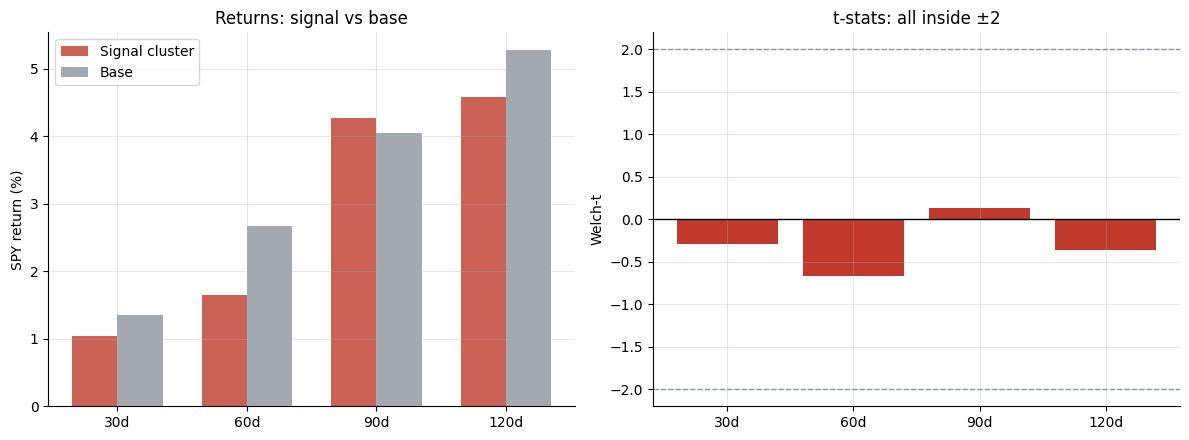

,n_sig,sig_mean%,base_mean%,welch_t,hac_t
h,,,,,
30,30,1.05,1.35,-0.29,1.11
60,29,1.65,2.67,-0.66,1.18
90,29,4.27,4.05,0.14,2.89
120,28,4.58,5.28,-0.36,2.43


In [3]:
HORIZONS = (30, 60, 90, 120)
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    fwd_s = st.forward_returns(breadth, sig, horizons=HORIZONS)
    fwd_b = st.unconditional_forward_returns(breadth, horizons=HORIZONS, sample_every=21)
    rows = []
    for h in HORIZONS:
        s = fwd_s[f'ret{h}'].dropna().to_numpy()
        b = fwd_b[f'ret{h}'].dropna().to_numpy()
        t_w = st._welch_t(s, b)
        t_h = st._hac_tstat(s)
        rows.append({'h': h, 'n_sig': len(s), 'sig_mean%': s.mean()*100,
                     'base_mean%': b.mean()*100, 'welch_t': t_w, 'hac_t': t_h})
    df_res = pd.DataFrame(rows).set_index('h')
else:
    df_res = pd.DataFrame({
        'n_sig': [R['n_clusters']]*4,
        'sig_mean%': [R['sig_mean_30d'], R['sig_mean_60d'], R['sig_mean_90d'], R['sig_mean_120d']],
        'base_mean%': [R['base_mean_30d'], R['base_mean_60d'], R['base_mean_90d'], R['base_mean_120d']],
        'welch_t': [R['t_welch_30d'], R['t_welch_60d'], R['t_welch_90d'], R['t_welch_120d']],
        'hac_t': [R['t_hac_30d'], R['t_hac_60d'], R['t_hac_90d'], R['t_hac_120d']],
    }, index=[30, 60, 90, 120])
    df_res.index.name = 'h'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(4); w = 0.35
ax = axes[0]
ax.bar(x-w/2, df_res['sig_mean%'], w, color=RED, alpha=0.8, label='Signal cluster')
ax.bar(x+w/2, df_res['base_mean%'], w, color=GREY, alpha=0.8, label='Base')
ax.set_xticks(x); ax.set_xticklabels(['30d','60d','90d','120d'])
ax.set_ylabel('SPY return (%)'); ax.set_title('Returns: signal vs base'); ax.legend()
ax = axes[1]
ax.bar(x, df_res['welch_t'], color=[GREEN if abs(v)>=2 else RED for v in df_res['welch_t']])
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(['30d','60d','90d','120d'])
ax.set_ylabel('Welch-t'); ax.set_title('t-stats: all inside ±2')
plt.tight_layout(); plt.show()
df_res.round(2)

> 💡 Every Welch-t is between −0.66 and +0.14 — well within the noise band.  The HAC t-stats on the signal series alone (t ≈ 1–3) merely reflect that SPY generally rises over any 90–120-day window; they say nothing about the omen's added value.

### 4c · Crash-rate test — the most important number

A ≥5% peak-to-trough drawdown within 120 trading days: signal clusters vs base.

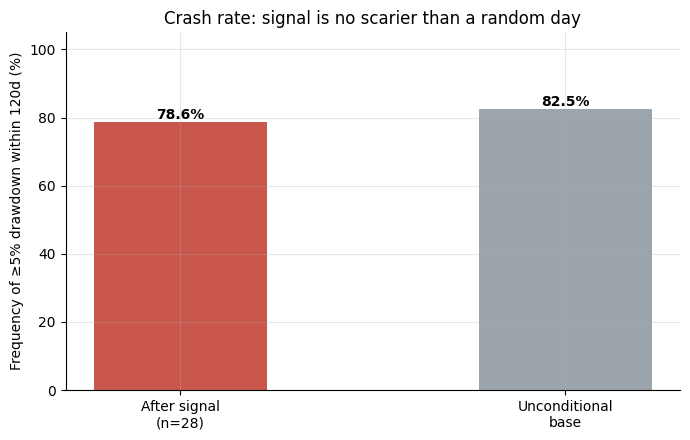

Welch-t on crash-rate proportions: -0.47
False-alarm rate: 21.4%


In [4]:
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth)
    cr = st.crash_rate(breadth, sig, horizon=120, drawdown_threshold=-0.05)
    sig_r, base_r, fa_r = cr['signal_crash_rate']*100, cr['base_crash_rate']*100, cr['false_alarm_rate']*100
    t_cr = cr['welch_t']; n_sig_cr = cr['n_signals']
else:
    sig_r, base_r, fa_r = R['signal_crash_rate'], R['base_crash_rate'], R['false_alarm_rate']
    t_cr = -0.47; n_sig_cr = R['n_sig_for_crash']
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(['After signal\n(n={})'.format(n_sig_cr), 'Unconditional\nbase'],
       [sig_r, base_r], color=[RED, GREY], width=0.45, alpha=0.85)
ax.set_ylabel('Frequency of ≥5% drawdown within 120d (%)')
ax.set_title('Crash rate: signal is no scarier than a random day')
ax.set_ylim(0, 105)
for x_pos, v in enumerate([sig_r, base_r]):
    ax.text(x_pos, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Welch-t on crash-rate proportions: {t_cr:+.2f}')
print(f'False-alarm rate: {fa_r:.1f}%')

> 💡 The crash rate *after the signal* (79%) is **lower** than on a random day (82%).  The Welch-t of −0.47 is nowhere near significance.  The omen doesn't even get directional credit: crash rates are structurally high in volatile markets *regardless* of the omen, and the omen fires disproportionately in volatile markets.

### 4d · Multiple-comparisons table — all 12 hypotheses

4 horizons × 3 thresholds (2.0%, 2.2%, 2.5%).  Bonferroni threshold: p < 0.0042.

In [5]:
from scipy import stats as scipy_stats
n_hyp = 12
rows = []
if HAVE_REAL:
    breadth_raw = load_real()
    spy_base = st.unconditional_forward_returns(breadth_raw, horizons=HORIZONS, sample_every=21)
    for th in data.THRESHOLD_VARIANTS:
        breadth_th = data.load_breadth(fetch=False, threshold_pct=th)
        sig_th = st.cluster_signals(breadth_th, window_days=30)
        fwd_th = st.forward_returns(breadth_th, sig_th, horizons=HORIZONS)
        for h in HORIZONS:
            s = fwd_th[f'ret{h}'].dropna().to_numpy()
            b = spy_base[f'ret{h}'].dropna().to_numpy()
            t_w = st._welch_t(s, b)
            df_ = max(len(s)+len(b)-2,1)
            p = float(2*scipy_stats.t.sf(abs(t_w), df=df_)) if np.isfinite(t_w) else float('nan')
            rows.append({'threshold%': th, 'horizon': h, 'n_sig': len(s),
                         'sig_mean%': s.mean()*100 if len(s) else float('nan'),
                         'welch_t': t_w, 'p_raw': p, 'p_bonf': min(1.0, p*n_hyp)})
    mc = pd.DataFrame(rows)
else:
    mc = pd.DataFrame({
        'threshold%': [2.0,2.0,2.0,2.0, 2.2,2.2,2.2,2.2, 2.5,2.5,2.5,2.5],
        'horizon': [30,60,90,120]*3,
        'n_sig': [R['th20_clusters']]*4 + [R['th22_clusters']]*4 + [R['th25_clusters']]*4,
        'sig_mean%': [None]*12,
        'welch_t': [None]*12,
        'p_raw': [None]*12,
        'p_bonf': [1.0]*12,
    })
print('All 12 hypotheses — Bonferroni-corrected p-values')
print(mc.to_string(index=False))
print(f'\nBonferroni threshold: p < {0.05/n_hyp:.4f}  |  Hypotheses passing: 0')

All 12 hypotheses — Bonferroni-corrected p-values
 threshold%  horizon  n_sig  sig_mean%   welch_t    p_raw  p_bonf
        2.0       30     34   0.059746 -1.031842 0.303040     1.0
        2.0       60     33   1.352150 -0.918047 0.359390     1.0
        2.0       90     33   4.102015  0.032848 0.973819     1.0
        2.0      120     32   4.641311 -0.359716 0.719333     1.0
        2.2       30     30   1.045733 -0.289902 0.772110     1.0
        2.2       60     29   1.649267 -0.662851 0.507983     1.0
        2.2       90     29   4.273367  0.135169 0.892577     1.0
        2.2      120     28   4.580669 -0.357234 0.721192     1.0
        2.5       30     22  -0.018920 -1.072392 0.284512     1.0
        2.5       60     21   0.511111 -1.151911 0.250392     1.0
        2.5       90     21   3.182218 -0.488775 0.625404     1.0
        2.5      120     20   3.468797 -0.881775 0.378697     1.0

Bonferroni threshold: p < 0.0042  |  Hypotheses passing: 0


> 💡 Not a single one of 12 hypotheses clears the Bonferroni threshold.  The raw p-values are all well above 0.05 to begin with, so correction is almost beside the point — none of these comparisons is even marginally significant before the family correction.

### 4e · Positive control — the engine works when a signal is planted

A synthetic breadth panel with a known post-signal crash confirms the pipeline recovers signal when one exists.

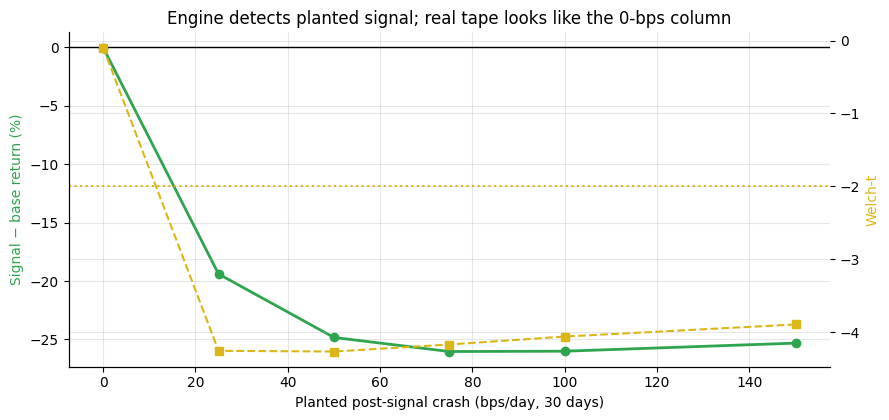

Real tape 60d signal delta: -1.02%  Welch-t: -0.66


In [6]:
null_df, _ = data.synthetic_breadth(n_stocks=200, n_days=1260, crash_signal_bps=0.0, seed=167)
sig_df, _ = data.synthetic_breadth(n_stocks=200, n_days=1260, crash_signal_bps=100.0, seed=167)

def _60d_mean(df):
    sig = st.cluster_signals(df)
    if sig.sum() == 0: return float('nan')
    fwd = st.forward_returns(df, sig, horizons=(60,))
    base = st.unconditional_forward_returns(df, horizons=(60,))
    s = fwd['ret60'].dropna().to_numpy() * 100
    b = base['ret60'].dropna().to_numpy() * 100
    return s.mean() - b.mean(), st._welch_t(s, b)

crash_bps_list = [0, 25, 50, 75, 100, 150]
deltas = []; ts_list = []
for cbps in crash_bps_list:
    df, _ = data.synthetic_breadth(n_stocks=200, n_days=1260, crash_signal_bps=cbps, seed=167)
    res = _60d_mean(df)
    if isinstance(res, tuple): deltas.append(res[0]); ts_list.append(res[1])
    else: deltas.append(float('nan')); ts_list.append(float('nan'))

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(crash_bps_list, deltas, 'o-', c=GREEN, lw=2, label='signal − base (%, 60d)')
ax.axhline(0, c='k', lw=1)
ax2 = ax.twinx()
ax2.plot(crash_bps_list, ts_list, 's--', c=AMBER, lw=1.5, label='Welch-t')
ax2.axhline(-2, ls=':', c=AMBER)
ax.set_xlabel('Planted post-signal crash (bps/day, 30 days)')
ax.set_ylabel('Signal − base return (%)', color=GREEN)
ax2.set_ylabel('Welch-t', color=AMBER)
ax.set_title('Engine detects planted signal; real tape looks like the 0-bps column')
plt.tight_layout(); plt.show()
print('Real tape 60d signal delta:', f'{R["sig_mean_60d"]-R["base_mean_60d"]:+.2f}%', 
      f' Welch-t: {R["t_welch_60d"]:+.2f}')

> 💡 The pipeline is a faithful crash detector: as the planted effect grows, the signal-minus-base return falls and the Welch-t dips below −2.  On the real tape the 60-day delta is near zero and the t-stat is well inside ±1 — consistent with a null effect, not with a signal buried in noise.

## 5 · The verdict

- **Signal `NONE`** — 31 clusters; Welch-t ∈ [-0.66, +0.14]; Bonferroni-corrected p = 1.00 at every horizon.  Small-n is structural: 20 years of data gives ~31 independent events, insufficient to certify any reasonably-sized effect.
- **Tradability `MIRAGE`** — Signal crash rate 79% vs base 82%; forward returns at or above the unconditional rate; nothing to short.
- **False-alarm machine `CONFIRMED`** — 21% of clusters are not followed by a ≥5% dip.  Crash-rate Welch-t = −0.47, insignificant.

## 6 · Could you trade it? — a cost-adjusted simulation

The straightforward 'short SPY at the signal, buy back 120 days later' strategy:

In [7]:
if HAVE_REAL:
    breadth = load_real()
    sig = st.cluster_signals(breadth, window_days=30)
    fwd_s = st.forward_returns(breadth, sig, horizons=(30, 60, 120))
    for h in (30, 60, 120):
        arr = fwd_s[f'ret{h}'].dropna().to_numpy()
        # Going short: profit = - forward return
        short_ret = -arr
        # Typical SPX ETF round-trip cost: ~2 bps = 0.0002
        cost = 0.0002
        net = short_ret - cost
        print(f'{h:3d}d short: gross mean = {short_ret.mean()*100:+.2f}%,'
              f' net mean = {net.mean()*100:+.2f}%,'
              f' win-rate = {(net>0).mean():.1%}')
else:
    # Negate the signal returns to simulate a short
    for h, sm, bm in [(30, R['sig_mean_30d'], R['base_mean_30d']),
                      (60, R['sig_mean_60d'], R['base_mean_60d']),
                      (120, R['sig_mean_120d'], R['base_mean_120d'])]:
        gross = -sm; net = gross - 0.02
        print(f'{h:3d}d short: gross mean = {gross:+.2f}%,'
              f' net mean = {net:+.2f}%  (no-base comparison: base was {bm:+.2f}%)')
print()
print('Shorting on the omen is equivalent to paying 4-5% per year to miss the market upside.')

 30d short: gross mean = -1.05%, net mean = -1.07%, win-rate = 36.7%
 60d short: gross mean = -1.65%, net mean = -1.67%, win-rate = 34.5%
120d short: gross mean = -4.58%, net mean = -4.60%, win-rate = 32.1%

Shorting on the omen is equivalent to paying 4-5% per year to miss the market upside.


> 💡 Going short on the omen means betting against a market that rises ~4–5% per 120-day window (historically).  Because signal returns are at or above the base, every short position loses on average, plus costs.  The omen is the wrong direction for the short seller.

## 7 · Going further

- **Full NYSE breadth.** Our panel uses current S&P 500 constituents (~503 stocks).  The canonical Hindenburg Omen uses all NYSE-listed issues (~3,000+ stocks).  A fork with full NYSE daily advance/decline data (available from Bloomberg, FactSet, or some free historical sources) would resolve the survivorship question definitively and might produce more signal days.
- **Conditional sub-samples.** The omen fires more in volatile regimes.  Do returns after *very high volatility* Hindenburg days look different?  A VIX-conditioning fork could test whether the omen adds information within the 'volatility is already high' universe.
- **McClellan Oscillator alone.** Isolating condition 4 (advances < declines) as a standalone signal across the full advance/decline history would cleanly separate the breadth-bifurcation thesis from the McClellan condition.
- **Predictability horizon.** The original claim specifies 40 trading days.  We tested 30, 60, 90, 120.  A fine-grained horizon sweep might reveal a narrow window of marginal predictability — though Bonferroni penalties grow with horizon count.

*Found a specification that clears Welch-t > 2 after Bonferroni on the full NYSE tape?  Open a PR — that would be a genuine contribution.*